RAW DATA
Shape: (15603, 11)
Columns: ['season', 'injury', 'days', 'games_missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league']

Rows after target cleaning: 15603

Days stats:
count    15603.000000
mean        36.102929
std         54.419842
min          1.000000
25%          9.000000
50%         18.000000
75%         39.000000
max       1013.000000
Name: days, dtype: float64

Model dataset shape: (15603, 28)

Bucket distribution:
days
8_21       5777
43_plus    3568
22_42      3363
0_7        2895
Name: count, dtype: int64


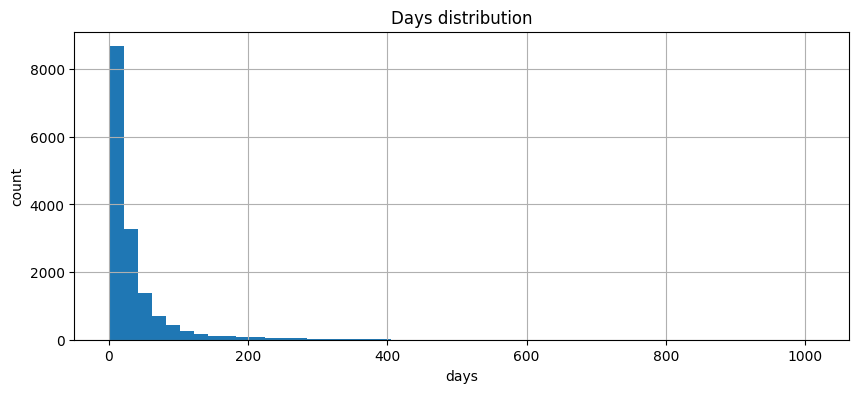

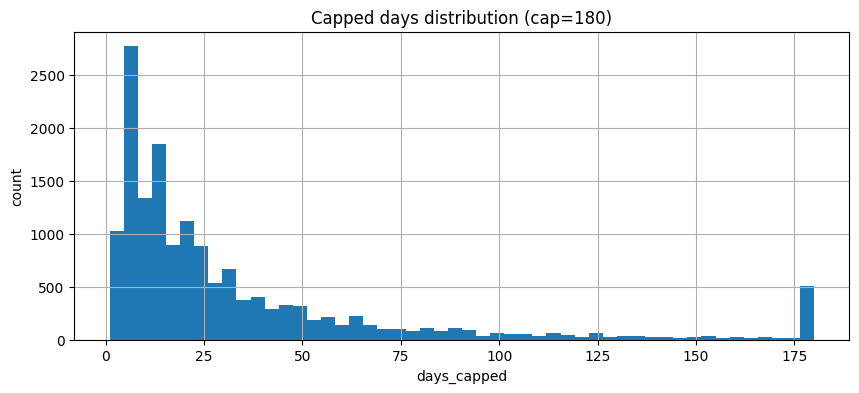

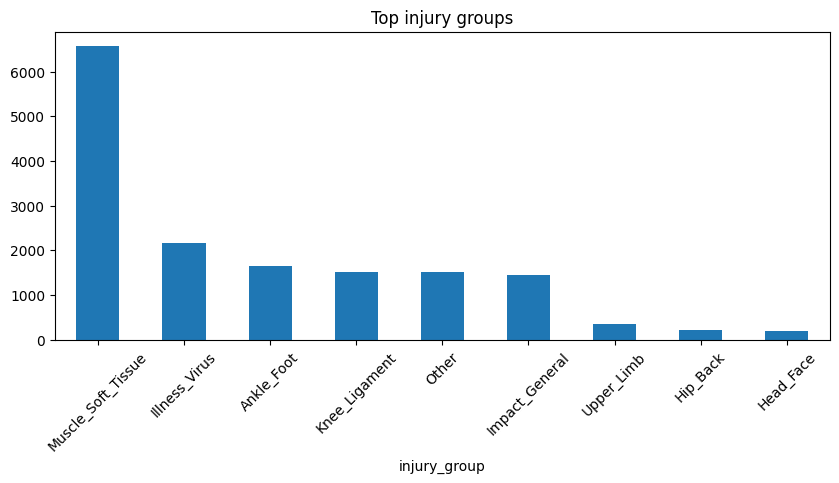


Train rows: 12336
Valid rows: 3267
0:	learn: 0.9526721	total: 7.94ms	remaining: 9.52s
100:	learn: 0.8425779	total: 669ms	remaining: 7.28s
200:	learn: 0.8293827	total: 1.36s	remaining: 6.79s
300:	learn: 0.8213544	total: 1.97s	remaining: 5.89s
400:	learn: 0.8133214	total: 2.67s	remaining: 5.31s
500:	learn: 0.8066005	total: 3.41s	remaining: 4.75s
600:	learn: 0.8007505	total: 4.15s	remaining: 4.13s
700:	learn: 0.7945010	total: 4.89s	remaining: 3.48s
800:	learn: 0.7891884	total: 5.6s	remaining: 2.79s
900:	learn: 0.7836447	total: 6.29s	remaining: 2.08s
1000:	learn: 0.7781818	total: 7.01s	remaining: 1.39s
1100:	learn: 0.7730743	total: 7.7s	remaining: 692ms
1199:	learn: 0.7678615	total: 8.4s	remaining: 0us

REGRESSION METRICS
{'mae_on_capped_days': 21.182317928160103, 'rmse_on_capped_days': 37.25962933650771, 'r2_on_capped_days': 0.09464651228945231}

BUCKET METRICS DERIVED FROM PREDICTED DAYS
{'macro_f1': 0.316499058105219, 'weighted_f1': 0.3413791035034143}

Classification report:
         

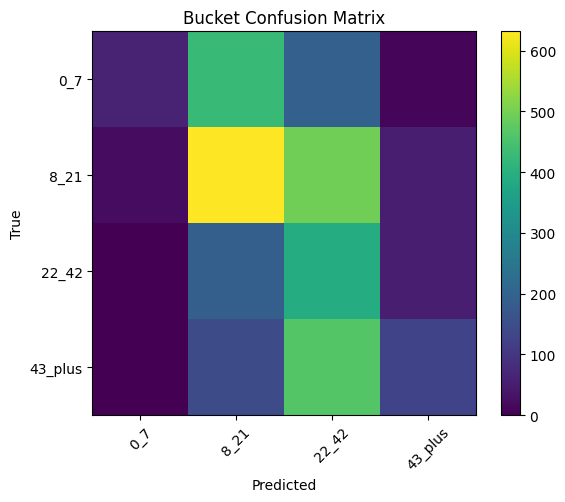


Top feature importances:
                feature  importance
1          injury_group   19.293933
4                  club   15.998540
11         season_phase   11.116453
0                season    7.412759
2            player_age    7.375210
3       player_position    7.139445
10    injury_weekofyear    6.285129
5                league    5.898032
9            injury_dow    5.144369
8            injury_day    4.297929
6           injury_year    4.199685
7          injury_month    2.756992
13       is_knee_injury    1.228297
14           is_illness    0.925864
12     is_muscle_injury    0.596493
15        is_ankle_foot    0.280945
16    is_impact_general    0.049926
17   player_age_missing    0.000000
18  injury_date_missing    0.000000


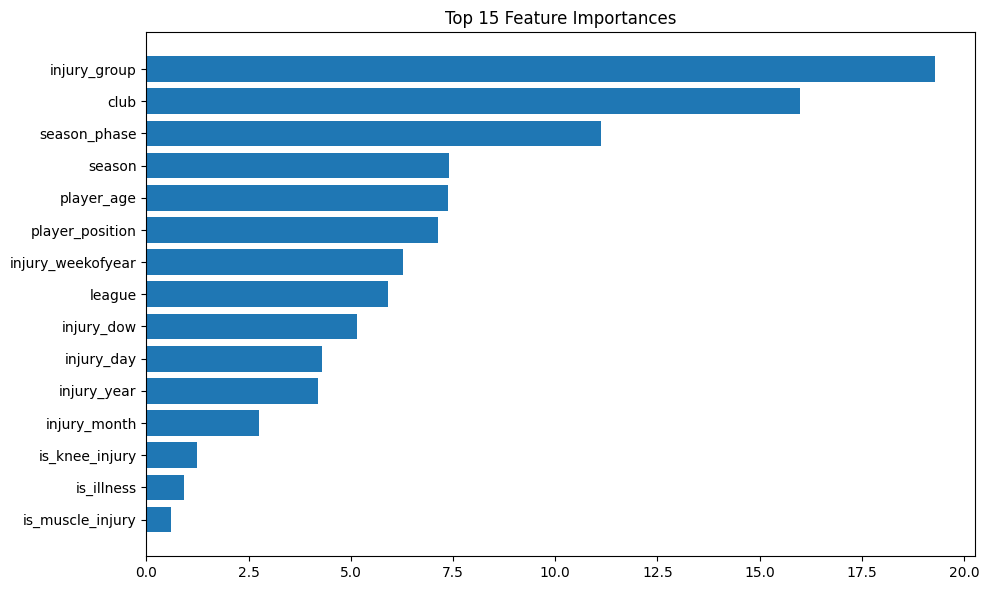


FILES SAVED
/kaggle/working/model_bundle/absence_days/model_absence_days.pkl
/kaggle/working/model_bundle/absence_days/absence_days_schema.json
/kaggle/working/model_bundle/absence_days/absence_days_metadata.json
/kaggle/working/model_bundle/absence_days/absence_days_sample_input.json
/kaggle/working/model_bundle/absence_days/absence_days_sample_output.json
/kaggle/working/model_bundle/absence_days/absence_days_validation_preview.csv
/kaggle/working/model_bundle/manifest.json

ABSENCE DAYS PREDICTION SUMMARY
Rows used for training/validation: 15603
Validation MAE: 21.1823
Validation RMSE: 37.2596
Validation R2: 0.0946
Derived bucket Macro F1: 0.3165
Derived bucket Weighted F1: 0.3414

DONE


In [3]:
# ============================================================
# ONE-CELL COMPLETE CODE
# ABSENCE DAYS PREDICTION / DAYS MISSED PREDICTION
# Kaggle / Google Colab ready
# ============================================================

import os
import re
import json
import math
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ============================================================
# 1) CONFIG
# ============================================================
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# CHANGE THIS PATH
# Kaggle example:
# CSV_PATH = "/kaggle/input/your-dataset-name/your_file.csv"
# Colab example:
# CSV_PATH = "/content/your_file.csv"
CSV_PATH = "/kaggle/input/datasets/sananmuzaffarov/european-football-injuries-2020-2025/full_dataset_thesis - 1.csv"

# Cap extreme values to stabilize regression
DAYS_CAP = 180

# Output folders
if os.path.exists("/kaggle/working"):
    BASE_OUTPUT_DIR = "/kaggle/working/model_bundle"
else:
    BASE_OUTPUT_DIR = "/content/model_bundle"

OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "absence_days")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUTPUT_DIR, "model_absence_days.pkl")
SCHEMA_PATH = os.path.join(OUTPUT_DIR, "absence_days_schema.json")
META_PATH = os.path.join(OUTPUT_DIR, "absence_days_metadata.json")
SAMPLE_INPUT_PATH = os.path.join(OUTPUT_DIR, "absence_days_sample_input.json")
SAMPLE_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "absence_days_sample_output.json")
VALID_PREVIEW_PATH = os.path.join(OUTPUT_DIR, "absence_days_validation_preview.csv")
MANIFEST_PATH = os.path.join(BASE_OUTPUT_DIR, "manifest.json")

# ============================================================
# 2) HELPERS
# ============================================================
def norm_col(c: str) -> str:
    c = str(c).strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def parse_days_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "nan", "none", "null", "-", "--", "?", "unknown", "n/a", "na"}:
        return np.nan
    s = s.replace(",", ".")
    s = re.sub(r"[^0-9\.\-]", "", s)
    if s in {"", ".", "-", "-."}:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def make_bucket(days: float) -> str:
    if days <= 7:
        return "0_7"
    elif days <= 21:
        return "8_21"
    elif days <= 42:
        return "22_42"
    return "43_plus"

def map_injury_group(text: str) -> str:
    if pd.isna(text):
        return "Unknown"
    s = str(text).lower()

    muscle_keywords = [
        "hamstring", "muscle", "adductor", "calf", "thigh",
        "groin", "strain", "tear", "muscular", "fiber", "bundle"
    ]
    knee_keywords = ["knee", "acl", "meniscus", "ligament", "patella"]
    ankle_foot_keywords = ["ankle", "foot", "toe", "achilles", "heel"]
    illness_keywords = ["ill", "virus", "covid", "corona", "flu", "infection", "fever", "sick"]
    impact_keywords = ["knock", "bruise", "contusion", "pain", "problem", "fitness"]
    upper_limb_keywords = ["shoulder", "arm", "elbow", "wrist", "hand"]
    head_face_keywords = ["head", "concussion", "face", "nose", "jaw"]
    hip_back_keywords = ["hip", "back", "spine", "pelvis"]

    if any(k in s for k in muscle_keywords):
        return "Muscle_Soft_Tissue"
    if any(k in s for k in knee_keywords):
        return "Knee_Ligament"
    if any(k in s for k in ankle_foot_keywords):
        return "Ankle_Foot"
    if any(k in s for k in illness_keywords):
        return "Illness_Virus"
    if any(k in s for k in impact_keywords):
        return "Impact_General"
    if any(k in s for k in upper_limb_keywords):
        return "Upper_Limb"
    if any(k in s for k in head_face_keywords):
        return "Head_Face"
    if any(k in s for k in hip_back_keywords):
        return "Hip_Back"
    return "Other"

def season_phase_from_month(month):
    if pd.isna(month):
        return "Unknown"
    month = int(month)
    if month in [7, 8, 9]:
        return "Early_Season"
    if month in [10, 11, 12, 1]:
        return "Mid_Season"
    if month in [2, 3, 4, 5]:
        return "Late_Season"
    return "Off_Season"

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["season", "injury", "player_name", "player_position", "club", "league"]:
        if c in out.columns:
            out[c] = out[c].astype(str).str.strip()

    if "player_age" in out.columns:
        out["player_age"] = pd.to_numeric(out["player_age"], errors="coerce")

    parsed = pd.to_datetime(out["injury_from_parsed"], errors="coerce")
    out["injury_group"] = out["injury"].apply(map_injury_group)
    out["injury_year"] = parsed.dt.year
    out["injury_month"] = parsed.dt.month
    out["injury_day"] = parsed.dt.day
    out["injury_dow"] = parsed.dt.dayofweek
    out["injury_weekofyear"] = parsed.dt.isocalendar().week.astype("float")
    out["season_phase"] = out["injury_month"].apply(season_phase_from_month)

    out["is_muscle_injury"] = (out["injury_group"] == "Muscle_Soft_Tissue").astype(int)
    out["is_knee_injury"] = (out["injury_group"] == "Knee_Ligament").astype(int)
    out["is_illness"] = (out["injury_group"] == "Illness_Virus").astype(int)
    out["is_ankle_foot"] = (out["injury_group"] == "Ankle_Foot").astype(int)
    out["is_impact_general"] = (out["injury_group"] == "Impact_General").astype(int)

    out["player_age_missing"] = out["player_age"].isna().astype(int)
    out["injury_date_missing"] = parsed.isna().astype(int)

    return out

def safe_rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def bucket_metrics_from_days(y_true_days, y_pred_days):
    y_true_bucket = pd.Series(y_true_days).apply(make_bucket)
    y_pred_bucket = pd.Series(y_pred_days).apply(make_bucket)

    macro_f1 = f1_score(y_true_bucket, y_pred_bucket, average="macro")
    weighted_f1 = f1_score(y_true_bucket, y_pred_bucket, average="weighted")
    report = classification_report(y_true_bucket, y_pred_bucket, output_dict=True)
    labels = ["0_7", "8_21", "22_42", "43_plus"]
    cm = confusion_matrix(y_true_bucket, y_pred_bucket, labels=labels)

    return {
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "report": report,
        "labels": labels,
        "confusion_matrix": cm.tolist(),
    }

# ============================================================
# 3) LOAD DATA
# ============================================================
if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df.columns = [norm_col(c) for c in df.columns]

required_cols = [
    "season", "injury", "days", "injury_from_parsed",
    "player_name", "player_age", "player_position", "club", "league"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("=" * 80)
print("RAW DATA")
print("=" * 80)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# keep row identity
df["row_id"] = np.arange(len(df))

# parse target
df["days_raw"] = df["days"]
df["days"] = df["days"].apply(parse_days_value)

# keep only rows with known target for training
df = df[df["days"].notna()].copy()
df = df[df["days"] >= 0].copy()
df = df.drop_duplicates().reset_index(drop=True)

print("\nRows after target cleaning:", len(df))
print("\nDays stats:")
print(df["days"].describe())

# parse dates
df["injury_from_parsed"] = pd.to_datetime(df["injury_from_parsed"], errors="coerce")
if "injury_until_parsed" in df.columns:
    df["injury_until_parsed"] = pd.to_datetime(df["injury_until_parsed"], errors="coerce")

# cap target for stability
df["days_capped"] = df["days"].clip(upper=DAYS_CAP)

# feature engineering
df = add_features(df)

feature_cols = [
    "season",
    "injury_group",
    "player_age",
    "player_position",
    "club",
    "league",
    "injury_year",
    "injury_month",
    "injury_day",
    "injury_dow",
    "injury_weekofyear",
    "season_phase",
    "is_muscle_injury",
    "is_knee_injury",
    "is_illness",
    "is_ankle_foot",
    "is_impact_general",
    "player_age_missing",
    "injury_date_missing",
]

categorical_cols = [
    "season",
    "injury_group",
    "player_position",
    "club",
    "league",
    "season_phase",
]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# prepare final model dataframe
model_df = df.copy()
for c in categorical_cols:
    model_df[c] = model_df[c].fillna("Unknown").astype(str)

model_df = model_df.dropna(subset=feature_cols + ["days_capped", "player_name"]).copy()

print("\nModel dataset shape:", model_df.shape)
print("\nBucket distribution:")
print(model_df["days"].apply(make_bucket).value_counts())

# ============================================================
# 4) EDA
# ============================================================
plt.figure(figsize=(10, 4))
model_df["days"].hist(bins=50)
plt.title("Days distribution")
plt.xlabel("days")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(10, 4))
model_df["days_capped"].hist(bins=50)
plt.title(f"Capped days distribution (cap={DAYS_CAP})")
plt.xlabel("days_capped")
plt.ylabel("count")
plt.show()

top_groups = model_df["injury_group"].value_counts().head(10)
plt.figure(figsize=(10, 4))
top_groups.plot(kind="bar")
plt.title("Top injury groups")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 5) TRAIN / VALID SPLIT
# ============================================================
groups = model_df["player_name"].fillna("unknown_player").astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, valid_idx = next(splitter.split(model_df, groups=groups))

train_df = model_df.iloc[train_idx].copy()
valid_df = model_df.iloc[valid_idx].copy()

X_train = train_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()

y_train_days = train_df["days_capped"].values
y_valid_days = valid_df["days_capped"].values

# smoother regression target
y_train_log = np.log1p(y_train_days)

print("\nTrain rows:", len(train_df))
print("Valid rows:", len(valid_df))

# ============================================================
# 6) MODEL
# ============================================================
try:
    from catboost import CatBoostRegressor, Pool
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
    from catboost import CatBoostRegressor, Pool

train_pool = Pool(X_train, label=y_train_log, cat_features=categorical_cols)
valid_pool = Pool(X_valid, cat_features=categorical_cols)

model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=100
)

model.fit(train_pool)

# ============================================================
# 7) VALIDATION
# ============================================================
pred_valid_log = model.predict(valid_pool)
pred_valid_days = np.expm1(pred_valid_log)
pred_valid_days = np.clip(pred_valid_days, 0, DAYS_CAP)

mae = mean_absolute_error(y_valid_days, pred_valid_days)
rmse = safe_rmse(y_valid_days, pred_valid_days)
r2 = r2_score(y_valid_days, pred_valid_days)

bucket_metrics = bucket_metrics_from_days(y_valid_days, pred_valid_days)

print("\n" + "=" * 80)
print("REGRESSION METRICS")
print("=" * 80)
print({
    "mae_on_capped_days": float(mae),
    "rmse_on_capped_days": float(rmse),
    "r2_on_capped_days": float(r2),
})

print("\n" + "=" * 80)
print("BUCKET METRICS DERIVED FROM PREDICTED DAYS")
print("=" * 80)
print({
    "macro_f1": bucket_metrics["macro_f1"],
    "weighted_f1": bucket_metrics["weighted_f1"],
})

print("\nClassification report:")
print(pd.DataFrame(bucket_metrics["report"]).T)

cm = np.array(bucket_metrics["confusion_matrix"])
labels = bucket_metrics["labels"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Bucket Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# validation preview
valid_preview = valid_df[[
    "row_id", "player_name", "injury", "club", "league", "season", "days", "days_capped"
]].copy()
valid_preview["predicted_days"] = np.round(pred_valid_days, 2)
valid_preview["true_bucket"] = valid_preview["days_capped"].apply(make_bucket)
valid_preview["pred_bucket"] = valid_preview["predicted_days"].apply(make_bucket)
valid_preview["abs_error"] = np.round(np.abs(valid_preview["days_capped"] - valid_preview["predicted_days"]), 2)
valid_preview.to_csv(VALID_PREVIEW_PATH, index=False)

# ============================================================
# 8) FEATURE IMPORTANCE
# ============================================================
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.get_feature_importance(train_pool)
}).sort_values("importance", ascending=False)

print("\nTop feature importances:")
print(feature_importance.head(20))

plt.figure(figsize=(10, 6))
plot_df = feature_importance.head(15).sort_values("importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# ============================================================
# 9) SAVE MODEL ARTIFACT
# ============================================================
model_artifact = {
    "model": model,
    "feature_columns": feature_cols,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "problem_name": "absence_days_prediction",
    "target_type": "regression_log1p_capped_days",
    "days_cap": DAYS_CAP,
    "output_field": "predicted_days",
}
joblib.dump(model_artifact, MODEL_PATH)

# ============================================================
# 10) SAVE SCHEMA
# ============================================================
schema = {
    "problem_name": "absence_days_prediction",
    "model_file": "model_absence_days.pkl",
    "model_type": "CatBoostRegressor",
    "target_type": "regression_log1p_capped_days",
    "days_cap": DAYS_CAP,
    "input_features_ordered": feature_cols,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "raw_required_columns_before_feature_engineering": [
        "season",
        "injury",
        "injury_from_parsed",
        "player_name",
        "player_age",
        "player_position",
        "club",
        "league",
    ],
    "feature_engineering_rules": {
        "injury_group": "mapped from raw injury text",
        "injury_year": "from injury_from_parsed",
        "injury_month": "from injury_from_parsed",
        "injury_day": "from injury_from_parsed",
        "injury_dow": "from injury_from_parsed",
        "injury_weekofyear": "from injury_from_parsed",
        "season_phase": "derived from injury_month",
        "is_muscle_injury": "1 if injury_group == Muscle_Soft_Tissue else 0",
        "is_knee_injury": "1 if injury_group == Knee_Ligament else 0",
        "is_illness": "1 if injury_group == Illness_Virus else 0",
        "is_ankle_foot": "1 if injury_group == Ankle_Foot else 0",
        "is_impact_general": "1 if injury_group == Impact_General else 0",
        "player_age_missing": "1 if player_age is missing else 0",
        "injury_date_missing": "1 if injury_from_parsed is missing else 0",
    },
    "days_parsing_rule": "parse_days_value keeps digits/./- then converts to float",
    "date_parsing_rule": "pd.to_datetime(..., errors='coerce') on injury_from_parsed",
    "output_contract": {
        "predicted_days": "float in [0, days_cap]",
        "severity_bucket": ["0_7", "8_21", "22_42", "43_plus"]
    },
    "bucket_definition": {
        "0_7": [0, 7],
        "8_21": [8, 21],
        "22_42": [22, 42],
        "43_plus": [43, None]
    }
}
with open(SCHEMA_PATH, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

# ============================================================
# 11) SAVE METADATA
# ============================================================
metadata = {
    "problem_name": "absence_days_prediction",
    "csv_path_used": CSV_PATH,
    "random_state": RANDOM_STATE,
    "row_count_after_cleaning": int(len(model_df)),
    "train_rows": int(len(train_df)),
    "valid_rows": int(len(valid_df)),
    "days_cap": DAYS_CAP,
    "regression_metrics": {
        "mae_on_capped_days": float(mae),
        "rmse_on_capped_days": float(rmse),
        "r2_on_capped_days": float(r2),
    },
    "bucket_metrics": {
        "macro_f1": float(bucket_metrics["macro_f1"]),
        "weighted_f1": float(bucket_metrics["weighted_f1"]),
    },
    "bucket_report": bucket_metrics["report"],
    "top_feature_importance": feature_importance.head(20).to_dict(orient="records"),
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# ============================================================
# 12) SAVE SAMPLE INPUT / OUTPUT
# ============================================================
sample_source = valid_df.iloc[0]

sample_input = {
    "season": str(sample_source["season"]),
    "injury": str(sample_source["injury"]),
    "injury_from_parsed": (
        str(pd.to_datetime(sample_source["injury_from_parsed"]).date())
        if pd.notna(sample_source["injury_from_parsed"]) else None
    ),
    "player_name": str(sample_source["player_name"]),
    "player_age": (
        float(sample_source["player_age"]) if pd.notna(sample_source["player_age"]) else None
    ),
    "player_position": str(sample_source["player_position"]),
    "club": str(sample_source["club"]),
    "league": str(sample_source["league"]),
}

sample_df = pd.DataFrame([sample_input])
sample_df["injury_from_parsed"] = pd.to_datetime(sample_df["injury_from_parsed"], errors="coerce")
sample_df = add_features(sample_df)

for c in categorical_cols:
    sample_df[c] = sample_df[c].fillna("Unknown").astype(str)

sample_X = sample_df[feature_cols].copy()
sample_pred_days = float(np.expm1(model.predict(sample_X)[0]))
sample_pred_days = float(np.clip(sample_pred_days, 0, DAYS_CAP))

sample_output = {
    "predicted_days": round(sample_pred_days, 2),
    "severity_bucket": make_bucket(sample_pred_days),
    "days_cap_used": DAYS_CAP,
    "problem_name": "absence_days_prediction",
}

with open(SAMPLE_INPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(sample_input, f, indent=2)

with open(SAMPLE_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(sample_output, f, indent=2)

# ============================================================
# 13) UPDATE MANIFEST
# ============================================================
manifest = {}
if os.path.exists(MANIFEST_PATH):
    try:
        with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
            manifest = json.load(f)
    except:
        manifest = {}

manifest["absence_days"] = {
    "problem_name": "absence_days_prediction",
    "model_file": os.path.relpath(MODEL_PATH, BASE_OUTPUT_DIR),
    "schema_file": os.path.relpath(SCHEMA_PATH, BASE_OUTPUT_DIR),
    "metadata_file": os.path.relpath(META_PATH, BASE_OUTPUT_DIR),
    "sample_input_file": os.path.relpath(SAMPLE_INPUT_PATH, BASE_OUTPUT_DIR),
    "sample_output_file": os.path.relpath(SAMPLE_OUTPUT_PATH, BASE_OUTPUT_DIR),
    "validation_preview_file": os.path.relpath(VALID_PREVIEW_PATH, BASE_OUTPUT_DIR),
    "main_metric_rmse": float(rmse),
    "main_metric_mae": float(mae),
    "main_metric_bucket_macro_f1": float(bucket_metrics["macro_f1"]),
    "version": "v1"
}

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# ============================================================
# 14) FINAL SUMMARY
# ============================================================
print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)
for p in [
    MODEL_PATH,
    SCHEMA_PATH,
    META_PATH,
    SAMPLE_INPUT_PATH,
    SAMPLE_OUTPUT_PATH,
    VALID_PREVIEW_PATH,
    MANIFEST_PATH,
]:
    print(p)

print("\n" + "=" * 80)
print("ABSENCE DAYS PREDICTION SUMMARY")
print("=" * 80)
print("Rows used for training/validation:", len(model_df))
print("Validation MAE:", round(mae, 4))
print("Validation RMSE:", round(rmse, 4))
print("Validation R2:", round(r2, 4))
print("Derived bucket Macro F1:", round(bucket_metrics["macro_f1"], 4))
print("Derived bucket Weighted F1:", round(bucket_metrics["weighted_f1"], 4))

print("\nDONE")